# 03. CTAB-GAN+ Oversampling
**GA-Optimized G-CTGAN: An Automated Oversampling Framework for Imbalanced Data Classification**

This notebook applies **CTAB-GAN+** (Zhao et al., IEEE TNNLS 2023) as a comparison method
across all benchmark datasets and classifiers.

> ⚠️ **Kernel**: Run this notebook with the `env_ctabgan` kernel.  
> CTAB-GAN+ is loaded directly from the cloned repository via `sys.path`.

Results are saved to `results/03_ctabgan_results.csv` and merged with baseline results in `06_classification.ipynb`.


## 0. Setup

In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ── CTAB-GAN-Plus repository path ──────────────────────────────────────
CTABGAN_REPO = r"C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\10_GA_G_CTGAG\CTAB-GAN-Plus"
if CTABGAN_REPO not in sys.path:
    sys.path.insert(0, CTABGAN_REPO)

from model.ctabgan import CTABGAN
print("CTABGAN loaded successfully.")

# ── Paths ──────────────────────────────────────────────────────────────
DATASET_DIR = "./datasets"
RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Experiment scope ───────────────────────────────────────────────────
# Excluded datasets and reasons (reported as N/A in results table):
#   - fraud_detection : IR=580, minority n=490 → GAN training unstable
#   - protein_homo    : IR=111, minority n=144 → GAN training unstable
#   - abalone_19      : IR=130, minority n=42  → GAN training unstable
#   - ibm_attrition   : one-hot encoded mixed-type columns cause infinite
#                       loop in CTABGANSynthesizer.inverse_transform()
DATASET_NAMES = [
    "credit_default",
    "pima_diabetes",
    "yeast_me2",
    "mammography",
    "wine_quality",
    "ecoli",
    "pageblocks",
]

# env_ctabgan: LGBM incompatible with sklearn version → RF, MLP only
# LGBM results for CTAB-GAN+ will be marked N/A in the results table
CLASSIFIERS   = ["RF", "MLP"]
UNIFIED_RATIO = 0.50

print(f"Datasets    : {len(DATASET_NAMES)}")
print(f"Classifiers : {CLASSIFIERS}")
print(f"Unified minority ratio: {UNIFIED_RATIO}")
print()
print("Excluded from CTAB-GAN+ experiment:")
print("  - fraud_detection, protein_homo, abalone_19 : extreme IR (>100)")
print("  - ibm_attrition : mixed-type inverse_transform incompatibility")

CTABGAN loaded successfully.
Datasets    : 7
Classifiers : ['RF', 'MLP']
Unified minority ratio: 0.5

Excluded from CTAB-GAN+ experiment:
  - fraud_detection, protein_homo, abalone_19 : extreme IR (>100)
  - ibm_attrition : mixed-type inverse_transform incompatibility


## 1. Classifier & Evaluation (same as 02_baselines)

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from lightgbm import LGBMClassifier

def get_classifier(name, random_state=RANDOM_STATE):
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=3,
            class_weight="balanced", random_state=random_state, n_jobs=-1,
        )
    elif name == "LGBM":
        return LGBMClassifier(
            n_estimators=100, learning_rate=0.05, num_leaves=31,
            class_weight="balanced", random_state=random_state, n_jobs=-1, verbose=-1,
        )
    elif name == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(128, 64), alpha=0.001,
            max_iter=300, random_state=random_state,
        )

def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        "AUC"      : round(roc_auc_score(y_test, y_prob), 4),
        "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
    }

print("Classifier and evaluation functions ready.")


Classifier and evaluation functions ready.


## 2. CTAB-GAN+ Oversampling Function

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def compute_n_samples(y_train, target_ratio=UNIFIED_RATIO):
    """Compute number of synthetic minority samples to reach target_ratio."""
    n_minority = int((y_train == 1).sum())
    n_majority = int((y_train == 0).sum())
    n_target   = int(n_majority * target_ratio / (1 - target_ratio))
    return max(0, n_target - n_minority)

def apply_ctabgan(X_train, y_train, random_state=RANDOM_STATE):
    n_synthetic = compute_n_samples(y_train)
    if n_synthetic == 0:
        return X_train, y_train

    X_min = X_train[y_train == 1].astype(float)
    cols  = [f"f{i}" for i in range(X_min.shape[1])]
    X_min_df = pd.DataFrame(X_min, columns=cols)

    tmp_path = "./datasets/_ctabgan_tmp.csv"
    X_min_df.to_csv(tmp_path, index=False)

    model = CTABGAN(
        raw_csv_path            = tmp_path,
        test_ratio              = 0.0,
        categorical_columns     = [],
        log_columns             = [],
        mixed_columns           = {},
        general_columns         = [],
        non_categorical_columns = [],
        integer_columns         = [],
        problem_type            = {False: None},
    )
    model.fit()

    # inverse_prep 우회 — synthesizer에서 numpy 직접 추출
    raw_syn = model.synthesizer.sample(n_synthetic)
    # raw_syn은 numpy array — DataFrame 변환만 수행
    if hasattr(raw_syn, "values"):
        X_syn = raw_syn.values.astype(float)
    else:
        X_syn = np.array(raw_syn).astype(float)

    # 컬럼 수 맞추기
    if X_syn.shape[1] > len(cols):
        X_syn = X_syn[:, :len(cols)]
    elif X_syn.shape[1] < len(cols):
        pad = np.zeros((X_syn.shape[0], len(cols) - X_syn.shape[1]))
        X_syn = np.hstack([X_syn, pad])

    # Trim or pad rows
    if len(X_syn) > n_synthetic:
        X_syn = X_syn[:n_synthetic]
    elif len(X_syn) < n_synthetic:
        shortage = n_synthetic - len(X_syn)
        X_syn = np.vstack([X_syn, X_syn[:shortage]])

    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    X_out = np.vstack([X_train.astype(float), X_syn])
    y_out = np.concatenate([y_train, np.ones(len(X_syn), dtype=int)])
    return X_out, y_out

print("CTAB-GAN+ oversampling function ready.")


CTAB-GAN+ oversampling function ready.


## 3. Main Experiment Loop

In [4]:
results = []
TOTAL = len(DATASET_NAMES) * len(CLASSIFIERS)
done  = 0

for ds_name in DATASET_NAMES:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        print(f"[SKIP] {ds_name} — file not found")
        done += len(CLASSIFIERS)
        continue

    df = pd.read_csv(path)
    X  = df.drop(columns=["target"]).values.astype(float)
    y  = df["target"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"\n{'='*60}")
    print(f"Dataset : {ds_name}  |  n_train={len(X_train):,}  |  minority={y_train.mean():.2%}")
    print(f"{'='*60}")

    # ── CTAB-GAN+ oversampling (once per dataset) ──────────────────
    t0 = time.time()
    try:
        X_res, y_res = apply_ctabgan(X_train.copy(), y_train.copy())
        oversample_time = round(time.time() - t0, 2)
        ratio_res = round((y_res == 1).sum() / len(y_res), 4)
        print(f"  CTAB-GAN+  n_resampled={len(y_res):,}  minority={ratio_res:.2%}  [{oversample_time:.1f}s]")
    except Exception as e:
        print(f"  CTAB-GAN+ oversampling failed: {e}")
        done += len(CLASSIFIERS)
        continue

    # ── Train & evaluate each classifier ──────────────────────────
    for clf_name in CLASSIFIERS:
        done += 1
        progress = f"[{done:>4}/{TOTAL}]"

        clf = get_classifier(clf_name)
        t1  = time.time()
        try:
            clf.fit(X_res, y_res)
            train_time = round(time.time() - t1, 2)
            metrics    = evaluate(clf, X_test, y_test)
        except Exception as e:
            print(f"  {progress} {ds_name} | CTAB-GAN+ | {clf_name:<7} — Failed: {e}")
            continue

        row = {
            "dataset"          : ds_name,
            "oversampling"     : "CTAB-GAN+",
            "classifier"       : clf_name,
            "n_train_resampled": len(y_res),
            "minority_ratio"   : ratio_res,
            "oversample_time"  : oversample_time,
            "train_time"       : train_time,
            **metrics,
        }
        results.append(row)

        print(f"  {progress} {ds_name} | CTAB-GAN+ | {clf_name:<7} | "
              f"AUC={metrics['AUC']:.4f}  F1={metrics['F1']:.4f}  [{train_time:.1f}s]")

print("\nExperiment complete.")



Dataset : credit_default  |  n_train=21,000  |  minority=22.12%


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [10:05<00:00,  4.04s/it]


Finished training in 612.4865419864655  seconds.
  CTAB-GAN+  n_resampled=32,710  minority=50.00%  [612.9s]
  [   1/14] credit_default | CTAB-GAN+ | RF      | AUC=0.7613  F1=0.4666  [0.6s]
  [   2/14] credit_default | CTAB-GAN+ | MLP     | AUC=0.7129  F1=0.4501  [78.9s]

Dataset : pima_diabetes  |  n_train=537  |  minority=34.82%


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:15<00:00,  9.47it/s]


Finished training in 16.141254425048828  seconds.
  CTAB-GAN+  n_resampled=700  minority=50.00%  [16.2s]
  [   3/14] pima_diabetes | CTAB-GAN+ | RF      | AUC=0.8363  F1=0.6667  [0.2s]
  [   4/14] pima_diabetes | CTAB-GAN+ | MLP     | AUC=0.7710  F1=0.6012  [1.5s]

Dataset : yeast_me2  |  n_train=1,038  |  minority=3.47%


...

Finished training in 16.380199670791626  seconds.
  CTAB-GAN+  n_resampled=6,600  minority=50.00%  [16.4s]
  [   9/14] wine_quality | CTAB-GAN+ | RF      | AUC=0.8503  F1=0.2683  [0.3s]
  [  10/14] wine_quality | CTAB-GAN+ | MLP     | AUC=0.8088  F1=0.3060  [16.1s]

Dataset : ecoli  |  n_train=235  |  minority=10.21%


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:14<00:00, 10.51it/s]


Finished training in 14.369998455047607  seconds.
  CTAB-GAN+  n_resampled=422  minority=50.00%  [14.4s]
  [  11/14] ecoli | CTAB-GAN+ | RF      | AUC=0.9737  F1=0.7000  [0.2s]
  [  12/14] ecoli | CTAB-GAN+ | MLP     | AUC=0.9414  F1=0.7200  [0.8s]

Dataset : pageblocks  |  n_train=3,831  |  minority=0.52%


100%|████████████████████████████████████████████████████████████████████████████████| 150/150 [00:15<00:00,  9.48it/s]


Finished training in 15.958998680114746  seconds.
  CTAB-GAN+  n_resampled=7,622  minority=50.00%  [16.0s]
  [  13/14] pageblocks | CTAB-GAN+ | RF      | AUC=0.9963  F1=0.5517  [0.2s]
  [  14/14] pageblocks | CTAB-GAN+ | MLP     | AUC=0.9959  F1=0.5926  [3.8s]

Experiment complete.


## 4. Save Results

In [5]:
results_df = pd.DataFrame(results)

save_path = os.path.join(RESULTS_DIR, "03_ctabgan_results.csv")
results_df.to_csv(save_path, index=False)
print(f"Results saved → {save_path}")
print(f"Total rows    : {len(results_df)}")
print()
print(results_df.groupby("classifier")["AUC"].mean().round(4).to_string())


Results saved → ./results\03_ctabgan_results.csv
Total rows    : 14

classifier
MLP    0.8472
RF     0.8968


## 5. Compare with Baselines

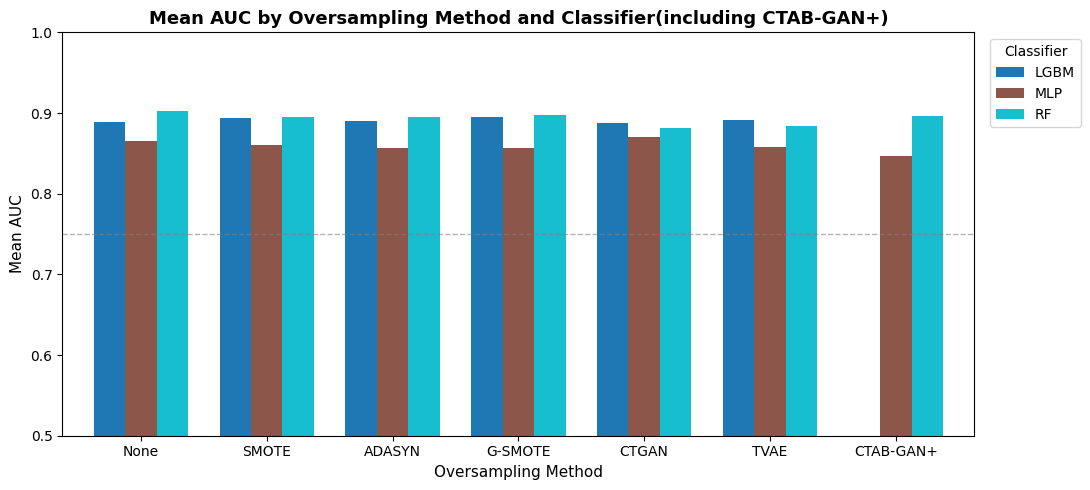

Figure saved → ./results\03_ctabgan_vs_baselines.png


In [7]:
import matplotlib.pyplot as plt

# Load baseline results for comparison
baseline_path = os.path.join(RESULTS_DIR, "02_baselines_results.csv")
if os.path.exists(baseline_path):
    baseline_df = pd.read_csv(baseline_path)
    combined_df = pd.concat([baseline_df, results_df], ignore_index=True)

    pivot = (combined_df
             .groupby(["oversampling", "classifier"])["AUC"]
             .mean()
             .unstack())

    METHOD_ORDER = ["None", "SMOTE", "ADASYN", "G-SMOTE", "CTGAN", "TVAE", "CTAB-GAN+"]
    pivot = pivot.reindex([m for m in METHOD_ORDER if m in pivot.index])

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot.plot(kind="bar", ax=ax, width=0.75, colormap="tab10")
    ax.set_title("Mean AUC by Oversampling Method and Classifier(including CTAB-GAN+)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Oversampling Method", fontsize=11)
    ax.set_ylabel("Mean AUC", fontsize=11)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.75, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.legend(title="Classifier", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()

    fig_path = os.path.join(RESULTS_DIR, "03_ctabgan_vs_baselines.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved → {fig_path}")
else:
    print("Baseline results not found. Run 02_baselines.ipynb first.")
